# 02 — Markov Chains
**Week 2 | Mathematical Foundations for RL**

Markov chains are the mathematical backbone of MDPs. The **Markov property** states:

$$P(s_{t+1} | s_t, s_{t-1}, ..., s_0) = P(s_{t+1} | s_t)$$

The future depends only on the present — not the history. This is what makes RL tractable.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
np.random.seed(0)

## 1. A Simple 3-State Markov Chain
States: Sunny (0), Cloudy (1), Rainy (2)

In [2]:
# Transition matrix T[i,j] = P(next=j | current=i)
T = np.array([
    [0.7, 0.2, 0.1],  # from Sunny
    [0.3, 0.4, 0.3],  # from Cloudy
    [0.2, 0.3, 0.5],  # from Rainy
])

state_names = ['Sunny', 'Cloudy', 'Rainy']

# Verify rows sum to 1
assert np.allclose(T.sum(axis=1), 1), "Rows must sum to 1!"
print("Transition matrix:")
print(T)

Transition matrix:
[[0.7 0.2 0.1]
 [0.3 0.4 0.3]
 [0.2 0.3 0.5]]


## 2. Simulate a Trajectory

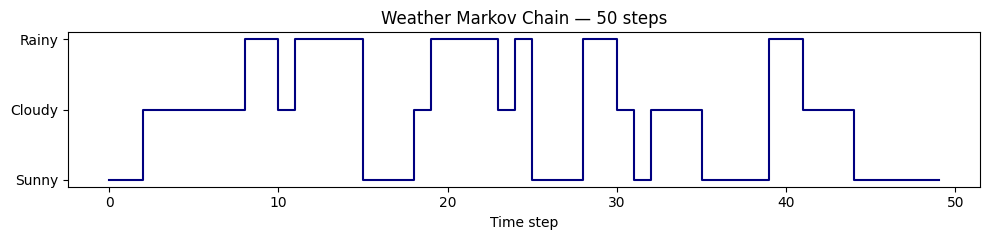

In [3]:
def simulate_markov(T, start_state, n_steps):
    trajectory = [start_state]
    state = start_state
    for _ in range(n_steps - 1):
        state = np.random.choice(len(T), p=T[state])
        trajectory.append(state)
    return np.array(trajectory)

traj = simulate_markov(T, start_state=0, n_steps=50)

plt.figure(figsize=(10, 2.5))
colors = ['gold', 'skyblue', 'steelblue']
plt.step(range(len(traj)), traj, where='post', color='navy', linewidth=1.5)
plt.yticks([0,1,2], state_names)
plt.xlabel('Time step'); plt.title('Weather Markov Chain — 50 steps')
plt.tight_layout(); plt.show()

## 3. Stationary Distribution
After many steps, the chain settles into a **stationary distribution** π where π = π · T.

We can find it as the left eigenvector of T corresponding to eigenvalue 1.

In [4]:
# Analytical: left eigenvector
eigenvalues, eigenvectors = np.linalg.eig(T.T)
idx = np.argmin(np.abs(eigenvalues - 1.0))  # eigenvalue closest to 1
stationary_analytical = np.real(eigenvectors[:, idx])
stationary_analytical /= stationary_analytical.sum()
print("Analytical stationary distribution:", np.round(stationary_analytical, 4))

# Empirical: simulate 100,000 steps
long_traj = simulate_markov(T, start_state=0, n_steps=100_000)
stationary_empirical = np.bincount(long_traj) / len(long_traj)
print("Empirical  stationary distribution:", np.round(stationary_empirical, 4))

Analytical stationary distribution: [0.4565 0.2826 0.2609]
Empirical  stationary distribution: [0.4574 0.2815 0.2612]


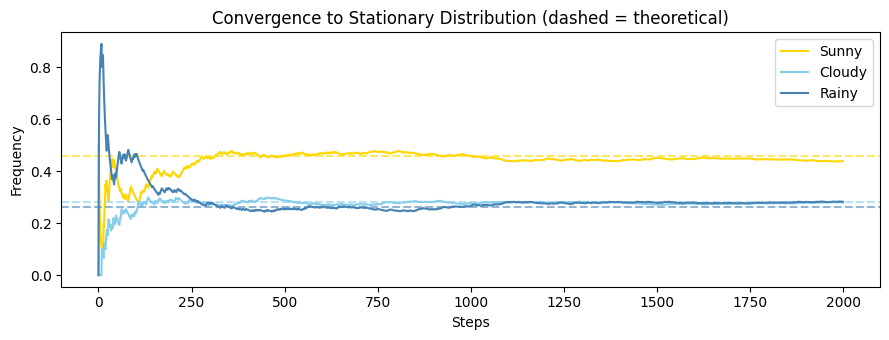

In [5]:
# Visualise convergence to stationary distribution
n_steps = 2000
state_freq = np.zeros((n_steps, 3))
traj_long = simulate_markov(T, start_state=0, n_steps=n_steps)
for t in range(1, n_steps):
    state_freq[t] = np.bincount(traj_long[:t+1], minlength=3) / (t+1)

fig, ax = plt.subplots(figsize=(9, 3.5))
colors_ = ['gold', 'skyblue', 'steelblue']
for i, (name, c) in enumerate(zip(state_names, colors_)):
    ax.plot(state_freq[:, i], color=c, linewidth=1.5, label=name)
    ax.axhline(stationary_analytical[i], color=c, linestyle='--', alpha=0.6)
ax.set_xlabel('Steps'); ax.set_ylabel('Frequency')
ax.set_title('Convergence to Stationary Distribution (dashed = theoretical)')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Matrix Power — Another View
P(state at t=n | start state) = T^n · initial_distribution

In [6]:
init = np.array([1.0, 0.0, 0.0])  # start in Sunny
print(f"t=0:  {init}")
Tn = T.copy()
for t in [1, 5, 10, 50]:
    Tn_power = np.linalg.matrix_power(T, t)
    dist = init @ Tn_power
    print(f"t={t:<3}: {np.round(dist, 4)}")  # should converge to stationary

t=0:  [1. 0. 0.]
t=1  : [0.7 0.2 0.1]
t=5  : [0.4685 0.2794 0.2521]
t=10 : [0.4568 0.2825 0.2607]
t=50 : [0.4565 0.2826 0.2609]


## ✅ Exercises
1. Change the transition matrix so that once it rains, it always rains next (absorbing state). What happens to the stationary distribution?
2. Add a 4th state (Stormy) to the chain. Update T, make sure rows sum to 1, and re-run.
3. **Challenge**: prove to yourself that `π @ T == π` for the stationary distribution you computed above. Write the assertion.

In [7]:
# Transition matrix T[i,j] = P(next=j | current=i)
T = np.array([
    [0.4, 0.2, 0.1, 0.3],  # from Sunny
    [0.3, 0.4, 0.2, 0.1],  # from Cloudy
    [0.0, 0.0, 1.0, 0.0],  # from Rainy
    [0.3, 0.3, 0.2, 0.2] # from stormy
])

state_names = ['Sunny', 'Cloudy', 'Rainy','Stormy']

# Verify rows sum to 1
assert np.allclose(T.sum(axis=1), 1), "Rows must sum to 1!"
print("Transition matrix:")
print(T)

Transition matrix:
[[0.4 0.2 0.1 0.3]
 [0.3 0.4 0.2 0.1]
 [0.  0.  1.  0. ]
 [0.3 0.3 0.2 0.2]]


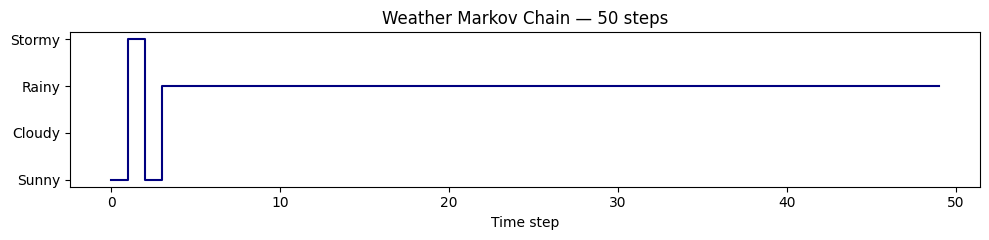

In [9]:
def simulate_markov(T, start_state, n_steps):
    trajectory = [start_state]
    state = start_state
    for _ in range(n_steps - 1):
        state = np.random.choice(len(T), p=T[state])
        trajectory.append(state)
    return np.array(trajectory)

traj = simulate_markov(T, start_state=0, n_steps=50)

plt.figure(figsize=(10, 2.5))
colors = ['gold', 'skyblue', 'steelblue']
plt.step(range(len(traj)), traj, where='post', color='navy', linewidth=1.5)
plt.yticks([0,1,2,3], state_names)
plt.xlabel('Time step'); plt.title('Weather Markov Chain — 50 steps')
plt.tight_layout(); plt.show()

In [10]:
# Analytical: left eigenvector
eigenvalues, eigenvectors = np.linalg.eig(T.T)
idx = np.argmin(np.abs(eigenvalues - 1.0))  # eigenvalue closest to 1
stationary_analytical = np.real(eigenvectors[:, idx])
stationary_analytical /= stationary_analytical.sum()
print("Analytical stationary distribution:", np.round(stationary_analytical, 4))

# Empirical: simulate 100,000 steps
long_traj = simulate_markov(T, start_state=0, n_steps=100_000)
stationary_empirical = np.bincount(long_traj) / len(long_traj)
print("Empirical  stationary distribution:", np.round(stationary_empirical, 4))

Analytical stationary distribution: [0. 0. 1. 0.]
Empirical  stationary distribution: [0. 0. 1. 0.]


In [13]:
init = np.array([1.0, 0.0, 0.0,0.0])  # start in Sunny
print(f"t=0:  {init}")
Tn = T.copy()
for t in [1, 5, 10, 50,100]:
    Tn_power = np.linalg.matrix_power(T, t)
    dist = init @ Tn_power
    print(f"t={t:<3}: {np.round(dist, 4)}")  # should converge to stationary

t=0:  [1. 0. 0. 0.]
t=1  : [0.4 0.2 0.1 0.3]
t=5  : [0.1829 0.1582 0.5486 0.1104]
t=10 : [0.0767 0.0664 0.8106 0.0463]
t=50 : [1.000e-04 1.000e-04 9.998e-01 0.000e+00]
t=100: [0. 0. 1. 0.]


In [ ]:
print(type(T))
print(type)

<class 'numpy.ndarray'>


#### Since it's a converging distribution, ie always it will end up raining, it is like mulitplying with the identity matrix, except only looking at one of the four columns. Thus, the resulting row would be the same as before, and pi *T ==pi

##### As expected, once the rain kicks in, it is going to stay rainy. Since we are considering a large no of trials, it is inevitable that rain will come sometime. And once it does, it will be stuck in that state, thus the stationary distribution remains stuck in that.